## Training and Evaluation of the Explainable Boosting Machine (EBM) on OpenML Dataset

This notebook trains 20 EBM models per fold (20 splits) and evaluates them using cross-validation.


In [1]:
# ============================================================================
# CONFIGURATION
# ============================================================================
OPENML_DATASET_ID = 31  # OpenML dataset ID
TASK_TYPE = "classification"  # Options: "classification" or "regression"
NUM_FOLDS = 5  # Number of folds for cross-validation
NUM_SPLITS = 20  # Number of splits per fold


In [2]:
import sys
from pathlib import Path

# Add src to path for imports
project_root = Path.cwd().parent.parent
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import neural_additive_models.data_utils as data_utils


In [3]:
dataset_name = f"OpenML_{OPENML_DATASET_ID}_{TASK_TYPE}"
is_regression = (TASK_TYPE == "regression")

print(f"Loading dataset: {dataset_name}")
data = data_utils.load_dataset(dataset_name)
data_x, data_y, column_names = data

print(f"Dataset shape: {data_x.shape}")
print(f"Target shape: {data_y.shape}")
print(f"Number of features: {data_x.shape[1]}")
print(f"Task type: {'Regression' if is_regression else 'Classification'}")

Loading dataset: OpenML_31_classification
Dataset shape: (1000, 61)
Target shape: (1000,)
Number of features: 61
Task type: Classification


In [4]:
from utils import create_fold_indices

fold_train_indices, fold_test_indices = create_fold_indices(
    data_x,
    data_y,
    num_folds=NUM_FOLDS,
    is_regression=is_regression,
    random_state=42
)


Instructions for updating:
non-resource variables are not supported in the long term


In [5]:
import json

# Load best hyperparameters from tuning results
results_dir = project_root / 'results' / 'hyperparameter_tuning' / 'ebm'
best_hp_file = results_dir / f'best_hp_{dataset_name.replace("/", "_").replace(":", "_")}.json'


with open(best_hp_file, 'r') as f:
    best_hp = json.load(f)
print(f"Loaded best hyperparameters from: {best_hp_file}")
print(f"Best hyperparameters:")
for key, value in best_hp.items():
    print(f"  {key}: {value}")


# Fixed hyperparameters

fixed_hp = {
    'random_state': 42,
    'n_jobs': -1,
    'early_stopping_rounds': 50,
    'validation_size': 0.125
}


Loaded best hyperparameters from: d:\Paul_is_great\WS2526\Seminar\neural-additive-models-xai-seminar\results\hyperparameter_tuning\ebm\best_hp_OpenML_31_classification.json
Best hyperparameters:
  learning_rate: 0.005558058369517066
  max_bins: 32
  max_interaction_bins: 8
  interactions: 20
  outer_bags: 16
  inner_bags: 0
  min_samples_leaf: 2
  max_leaves: 5


## Train 20 Models Per Fold

This section trains 20 EBM models for each fold (20 splits per fold), matching the NAM training methodology. Each model uses a unique random seed to ensure diversity: `seed = (fold - 1) * num_splits + split`.

Models are saved to disk and will be reused if they already exist, allowing for efficient re-runs of the evaluation.


In [6]:
from utils import gather_ebm_predictions_and_shape_functions
import numpy as np

# Set results directory for saving models
base_logdir = project_root / 'results' / 'training' / 'ebm' / f'openml_{OPENML_DATASET_ID}_{TASK_TYPE}'

print("="*70)
print("TRAINING 20 MODELS PER FOLD")
print("="*70)
print(f"Number of folds: {NUM_FOLDS}")
print(f"Number of splits per fold: {NUM_SPLITS}")
print(f"Total models to train: {NUM_FOLDS * NUM_SPLITS}")
print(f"Models will be saved to: {base_logdir}")
print("="*70)
print("\nNote: Models are trained on-demand if they don't already exist.")
print("Each model uses a unique random seed: seed = (fold - 1) * num_splits + split")
print("\nGathering predictions and shape functions (training models as needed)...")
print("="*70)

all_preds_per_fold, all_shape_functions, all_mean_pred = gather_ebm_predictions_and_shape_functions(
    fold_test_indices=fold_test_indices,
    data_x=data_x,
    data_y=data_y,
    column_names=column_names,
    dataset_name=dataset_name,
    best_hp=best_hp,
    fixed_hp=fixed_hp,
    is_regression=is_regression,
    num_folds=NUM_FOLDS,
    num_splits=NUM_SPLITS,
    print_every=5,
    base_logdir=str(base_logdir)
)


TRAINING 20 MODELS PER FOLD
Number of folds: 5
Number of splits per fold: 20
Total models to train: 100
Models will be saved to: d:\Paul_is_great\WS2526\Seminar\neural-additive-models-xai-seminar\results\training\ebm\openml_31_classification

Note: Models are trained on-demand if they don't already exist.
Each model uses a unique random seed: seed = (fold - 1) * num_splits + split

Gathering predictions and shape functions (training models as needed)...
Processing fold 1 (test set size: 200)...
  Processing split 1/20... (trained)
  Processing split 5/20... (trained)
  Processing split 10/20... (trained)
  Processing split 15/20... (trained)
  Processing split 20/20... (trained)
Processing fold 2 (test set size: 200)...
  Processing split 1/20... (trained)
  Processing split 5/20... (trained)
  Processing split 10/20... (trained)
  Processing split 15/20... (trained)
  Processing split 20/20... (trained)
Processing fold 3 (test set size: 200)...
  Processing split 1/20... (trained)
  P

In [7]:
from utils import save_performance_metrics

# Save detailed performance metrics for statistical analysis
output_file = save_performance_metrics(
    all_preds_per_fold=all_preds_per_fold,
    fold_test_indices=fold_test_indices,
    data_y=data_y,
    dataset_id=OPENML_DATASET_ID,
    dataset_name=dataset_name,
    task_type=TASK_TYPE,
    model_type='EBM',
    num_folds=NUM_FOLDS,
    num_splits=NUM_SPLITS,
    is_regression=is_regression,
    project_root=project_root,
    verbose=True
)



PERFORMANCE METRICS SAVED
Saved to: d:\Paul_is_great\WS2526\Seminar\neural-additive-models-xai-seminar\results\evaluation\ebm_OpenML_31_classification_performance.json
Summary:
  Mean AUC: 0.7682
  Std AUC: 0.0226
  Min AUC: 0.7427
  Max AUC: 0.8018


In [8]:
from utils import evaluate_ensemble_across_folds

fold_metrics, avg_metric, std_metric = evaluate_ensemble_across_folds(
    all_preds_per_fold,
    fold_test_indices,
    data_y,
    is_regression=is_regression,
    verbose=True
)


Fold 1 AUC (test set only): 0.7479 (n=200)
Fold 2 AUC (test set only): 0.7427 (n=200)
Fold 3 AUC (test set only): 0.7620 (n=200)
Fold 4 AUC (test set only): 0.8018 (n=200)
Fold 5 AUC (test set only): 0.7865 (n=200)

Average Ensemble AUC across folds (test sets only): 0.7682
Std of Ensemble AUC across folds: 0.0226


Auto-calculated y-axis limits: (-1.51, 1.88)


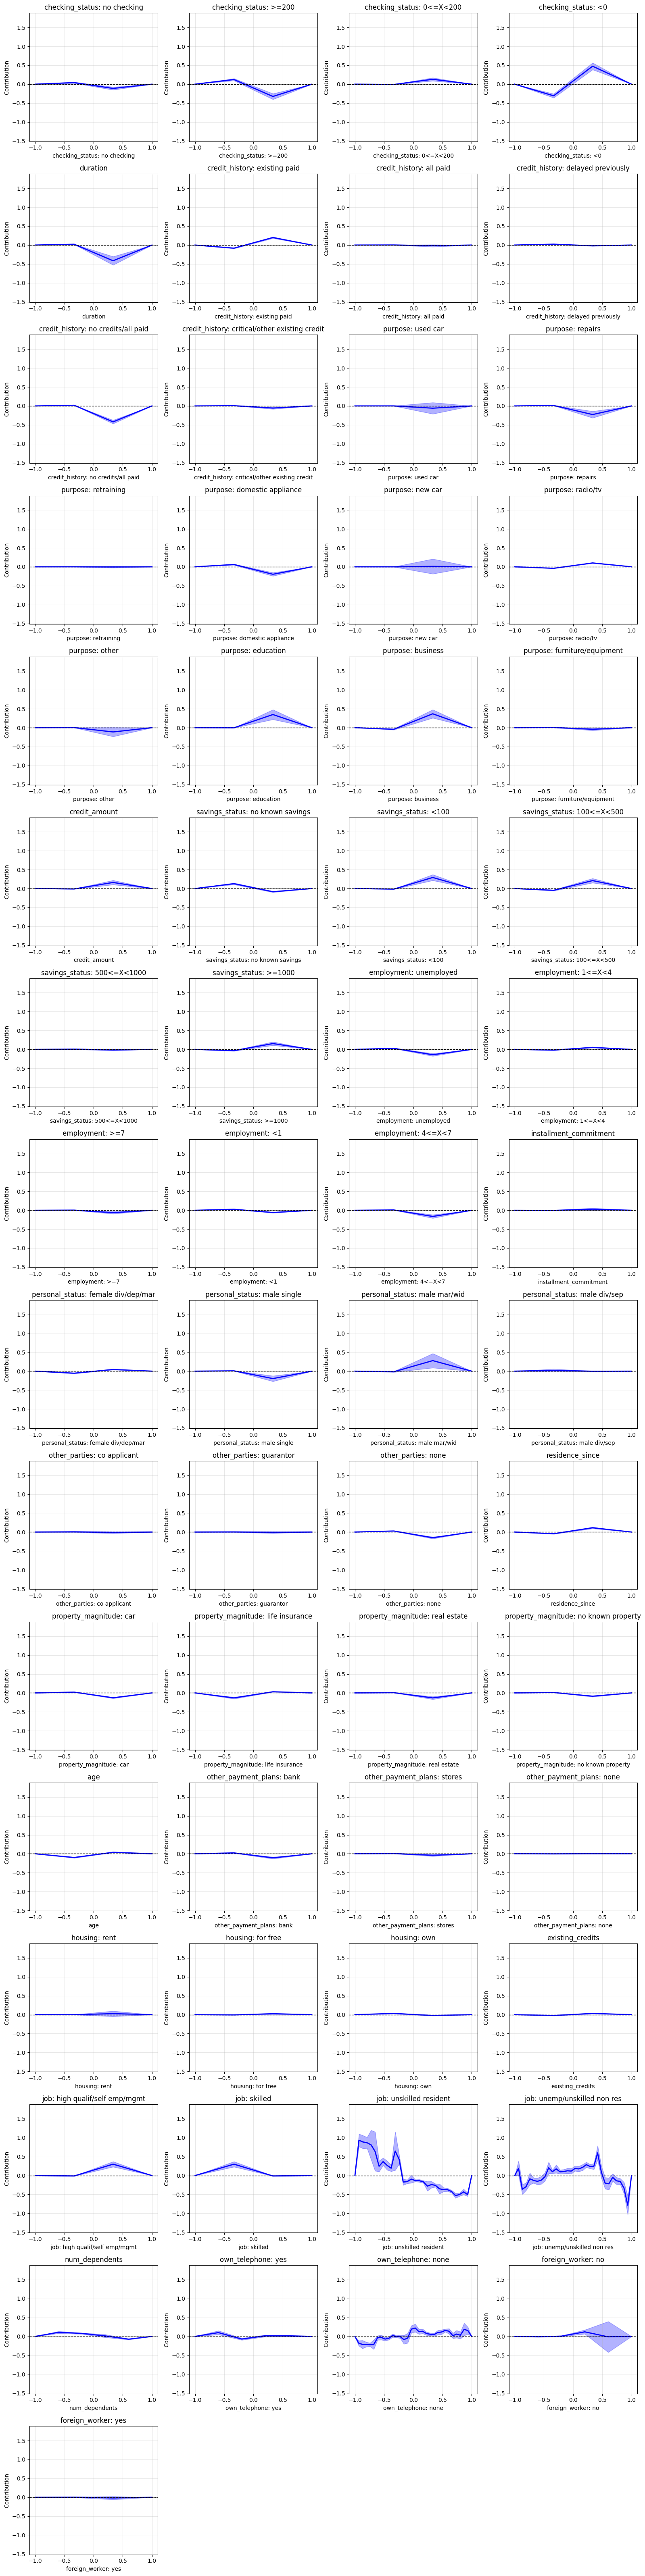

In [9]:
from utils import plot_ebm_shape_functions

# Calculate y-axis limits automatically from shape function data
import numpy as np

all_y_values = []
for shape_data in all_shape_functions:
    for feat_name in shape_data:
        feat_data = shape_data[feat_name]
        if 'y' in feat_data:
            all_y_values.extend(feat_data['y'])

if all_y_values:
    y_min = np.min(all_y_values)
    y_max = np.max(all_y_values)
    y_range = y_max - y_min
    # Add 10% padding on each side
    padding = y_range * 0.1
    y_limits = (y_min - padding, y_max + padding)
    print(f"Auto-calculated y-axis limits: ({y_limits[0]:.2f}, {y_limits[1]:.2f})")
else:
    y_limits = (-0.1, 0.1)  # Default fallback
    print("No shape function data found, using default y-axis limits")

# Plot average shape functions across all splits
fig = plot_ebm_shape_functions(
    column_names=column_names,
    all_shape_functions=all_shape_functions,
    y_limits=y_limits
)
